In [1]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('/home/intellect-1001/Desktop/Data_Scientist-/Day 4 FN-20251212T063722Z-1-001/Day 4 FN/vin6.project/Mall_Customers (1).csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
from sklearn.cluster import AgglomerativeClustering
hierarchical = AgglomerativeClustering(n_clusters=3,linkage='ward')

In [6]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values


In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns
X = df[numeric_cols].values

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
labels=df['CustomerID'].values


In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns
X = df[numeric_cols].values

In [11]:
linkage_matrix = linkage(X_scaled, method='ward')

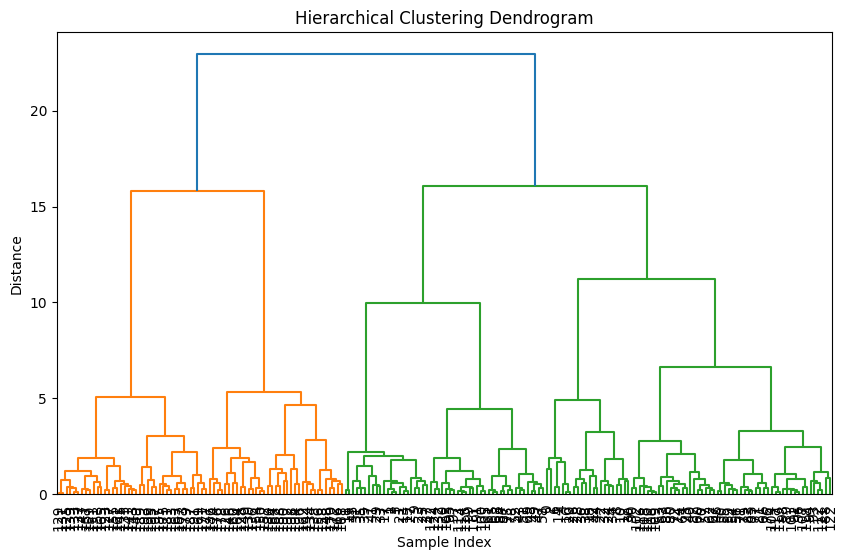

In [12]:
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, labels=df.index, leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

In [13]:
import joblib
joblib.dump(hierarchical, 'hierarchical_model.pkl')


['hierarchical_model.pkl']